In [6]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [7]:
library(survival)
library(survminer)


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [8]:

library(rms)

Loading required package: Hmisc


Attaching package: ‘Hmisc’


The following object is masked from ‘package:MOFA2’:

    impute


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




In [9]:
path = "survival_merged_data_cs_baseline_final_final.csv"
sample_data = read.csv(path)
rownames(sample_data) = sample_data$Labor.IDs
head(sample_data)


,X,Labor.IDs,enrol_inclusiondate,enrol_tx_inv_ventilation,dc_1_death_intrahosp,endpoint_organ_support_lactate_catecholamine,need.for.organ.support..MCS..dialysis..intubation.NIV..HTx..LVAD.,endpoint_organ_support_death_lactate_catecholamine,endpoint_organ_support_death,dc_1_date_of_death,⋯,event_catecholamines_14,time_catecholamines_days_14,event_catecholamines_7,time_catecholamines_days_7,plate,condition,tp,Patient,Day,s1
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>
LCLC100040,3,LCLC100040,21/08/2019,0,1,low_risk,Dialysis,high_risk,high_risk,14/03/2022,⋯,1,0.08333333,1,0.08333333,plate 2,UKE-CS,1,40,Baseline,-0.07462691
LCLC100111,14,LCLC100111,9/11/2020,0,0,low_risk,Dialysis,low_risk,low_risk,,⋯,NA,0.00000000,NA,0.00000000,plate 5,UKE-CS,1,111,Baseline,0.12120792
LCLC100050,6,LCLC100050,8/10/2019,0,0,low_risk,Dialysis,low_risk,low_risk,,⋯,NA,0.00000000,NA,0.00000000,plate 8,UKE-CS,1,50,Baseline,-0.05415195
LCLC100190,28,LCLC100190,6/04/2022,0,0,low_risk,0,low_risk,low_risk,,⋯,NA,0.00000000,NA,0.00000000,plate 6,UKE-CS,1,190,Baseline,-0.36471297
LCLC100359,52,LCLC100359,22/11/2023,0,0,low_risk,0,low_risk,low_risk,,⋯,NA,0.00000000,NA,0.00000000,plate 3,UKE-CS,1,359,Baseline,-0.75316030
LCLC100227,42,LCLC100227,28/09/2022,0,0,low_risk,0,low_risk,low_risk,,⋯,NA,0.00000000,NA,0.00000000,plate 9,UKE-CS,1,227,Baseline,-0.53510648


In [10]:
rownames(sample_data) = sample_data$Labor.IDs

In [11]:
final_merged_data = read.csv("final_merged_data_cs_baseline_final.csv")
rownames(final_merged_data) = final_merged_data$Labor.IDs
final_merged_data = final_merged_data[rownames(sample_data), ]
head(final_merged_data)

,X,Labor.IDs,Data.IDs,enrol_inclusiondate,enrol_dob_year,enrol_sex,enrol_height,enrol_mh_hf_fd,enrol_rf_aht,enrol_rf_dm,⋯,inhfu_2_fu_intrahosp_timestamp,justification.to.reclassify.as.CS,X.y,plate,barcode,condition,tp,Patient,Day,s1
,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>
LCLC100040,3,LCLC100040,DCLC100040,21/08/2019,1975,1,153,NA,1,5,⋯,,SCAI C at enrol,38,plate 2,AGAGTAATGCCA,UKE-CS,1,40,Baseline,-0.07462691
LCLC100111,14,LCLC100111,DCLC100111,9/11/2020,1949,0,175,4,1,0,⋯,13/11/2020 12:29,"Dialysis (SCAI never C or above), CKD at admission but inhosp initiation of dialysis",105,plate 5,ACATAAGTCAGG,UKE-CS,1,111,Baseline,0.12120792
LCLC100050,6,LCLC100050,DCLC100050,8/10/2019,1947,0,172,4,1,3,⋯,12/10/2019 7:00,"Dialysis (SCAI never C or above), CKD at admission, but initiation of dialysis inhosp",48,plate 8,CTCTTCTACTAG,UKE-CS,1,50,Baseline,-0.05415195
LCLC100190,28,LCLC100190,DCLC100190,6/04/2022,1930,1,156,4,1,0,⋯,10/04/2022 8:00,SCAI C at enrolement,178,plate 6,AGCGGTAGATTA,UKE-CS,1,190,Baseline,-0.36471297
LCLC100359,52,LCLC100359,DCLC100359,22/11/2023,1949,0,180,1,0,0,⋯,,SCAI C at enrolement,261,plate 3,CGACCATACCTG,UKE-CS,1,359,Baseline,-0.75316030
LCLC100227,42,LCLC100227,DCLC100227,28/09/2022,1958,1,139,4,1,0,⋯,2/10/2022 8:00,SCAI C at enrolement,214,plate 9,TGACCTCTGGTA,UKE-CS,1,227,Baseline,-0.53510648


In [12]:
colnames(final_merged_data)

[1] "X"                                                                
  [2] "Labor.IDs"                                                        
  [3] "Data.IDs"                                                         
  [4] "enrol_inclusiondate"                                              
  [5] "enrol_dob_year"                                                   
  [6] "enrol_sex"                                                        
  [7] "enrol_height"                                                     
  [8] "enrol_mh_hf_fd"                                                   
  [9] "enrol_rf_aht"                                                     
 [10] "enrol_rf_dm"                                                      
 [11] "enrol_rf_hyperchol"                                               
 [12] "enrol_rf_smoking"                                                 
 [13] "enrol_mh_cad"                                                     
 [14] "enrol_mh_ckd"                                                     
 [15] "enrol_cycle_admissiontype"                                        
 [16] "enrol_ahf_trigger"                                                
 [17] "enrol_cpr___0"                                                    
 [18] "enrol_cpr___1"                                                    
 [19] "enrol_cpr___2"                                                    
 [20] "enrol_cpr___unk"                                                  
 [21] "enrol_cpr___na"                                                   
 [22] "enrol_tx_prehosp_cpr_rhythm"                                      
 [23] "enrol_tx_prehosp_cpr_ecpr"                                        
 [24] "enrol_tx_prehosp_cpr_rosc"                                        
 [25] "enrol_hfstatus_mcs_active"                                        
 [26] "enrol_weight"                                                     
 [27] "enrol_cp_oedema"                                                  
 [28] "enrol_cp_nyha"                                                    
 [29] "enrol_cp_hf_intermacs"                                            
 [30] "enrol_cp_hf_scai"                                                 
 [31] "enrol_cp_nohria"                                                  
 [32] "enrol_cp_bps"                                                     
 [33] "enrol_cp_bpd"                                                     
 [34] "enrol_cp_map"                                                     
 [35] "enrol_cp_hr"                                                      
 [36] "enrol_bga_lactate_worst"                                          
 [37] "enrol_bga_ph_worst"                                               
 [38] "enrol_tx_inv_ventilation"                                         
 [39] "enrol_tx_niv"                                                     
 [40] "enrol_tx_med_loopd_iv24h"                                         
 [41] "enrol_tx_med_loopd_iv24h_dose"                                    
 [42] "enrol_tx_med_dobutamine"                                          
 [43] "enrol_tx_med_epinephrine"                                         
 [44] "enrol_tx_med_norepinephrine"                                      
 [45] "enrol_tx_med_milrinone"                                           
 [46] "enrol_tx_med_inotropic_score"                                     
 [47] "enrol_tx_med_levosimendane"                                       
 [48] "enrol_cpr_24h"                                                    
 [49] "enrol_tte_lvef"                                                   
 [50] "enrol_tte_lvef_semiquant"                                         
 [51] "enrol_tte_tapse"                                                  
 [52] "enrol_lab_creatinine"                                             
 [53] "enrol_lab_gfr_creatinine"                                         
 [54] "enrol_lab_asat"                                                   
 [55] 

In [13]:
colnames(sample_data)


[1] "X"                                                                
 [2] "Labor.IDs"                                                        
 [3] "enrol_inclusiondate"                                              
 [4] "enrol_tx_inv_ventilation"                                         
 [5] "dc_1_death_intrahosp"                                             
 [6] "endpoint_organ_support_lactate_catecholamine"                     
 [7] "need.for.organ.support..MCS..dialysis..intubation.NIV..HTx..LVAD."
 [8] "endpoint_organ_support_death_lactate_catecholamine"               
 [9] "endpoint_organ_support_death"                                     
[10] "dc_1_date_of_death"                                               
[11] "dc_Dead_death_intrahosp_30_day_binary"                            
[12] "dc_1_death_intrahosp_30_day"                                      
[13] "death_30_day"                                                     
[14] "dc_Dead_death_intrahosp_28_day_binary"                            
[15] "dc_1_death_intrahosp_28_day"                                      
[16] "death_28_day"                                                     
[17] "death_14_day"                                                     
[18] "dc_1_death_intrahosp_14_day"                                      
[19] "dc_Dead_death_intrahosp_Dead4_day_binary"                         
[20] "death"                                                            
[21] "death_50_day"                                                     
[22] "dc_1_death_intrahosp_50_day"                                      
[23] "dc_1_discharge"                                                   
[24] "dc_1_dischargedate"                                               
[25] "lactate.clearance..2.mM"                                          
[26] "lacate_clearance_time_days"                                       
[27] "weaning.off.of.catecholamines"                                    
[28] "event_catecholamines"                                             
[29] "time_catecholamines_days"                                         
[30] "event_catecholamines_28"                                          
[31] "time_catecholamines_days_28"                                      
[32] "event_catecholamines_14"                                          
[33] "time_catecholamines_days_14"                                      
[34] "event_catecholamines_7"                                           
[35] "time_catecholamines_days_7"                                       
[36] "plate"                                                            
[37] "condition"                                                        
[38] "tp"                                                               
[39] "Patient"                                                          
[40] "Day"                                                              
[41] "s1"

In [14]:
top_500_factor3_genes = read.csv("predicted_values_top_500_factor3_genes_uke.csv")

In [15]:
head(top_500_factor3_genes)

,X,s1
,<chr>,<dbl>
1,LCLC100001,0.08045102
2,LCLC100002,0.17444418
3,LCLC100003,-0.20706624
4,LCLC100004,0.17511966
5,LCLC100005,-0.34439143
6,LCLC100006,-0.35838816


In [16]:
rownames(top_500_factor3_genes) = top_500_factor3_genes$X



In [17]:
nrow(top_500_factor3_genes)

[1] 1016

In [18]:
nrow(sample_data)

[1] 112

In [19]:
common_samples = intersect(rownames(sample_data), rownames(top_500_factor3_genes))


In [20]:
common_samples

[1] "LCLC100040" "LCLC100111" "LCLC100050" "LCLC100190" "LCLC100359"
  [6] "LCLC100227" "LCLC100216" "LCLC100231" "LCLC100337" "LCLC100340"
 [11] "LCSC100033" "LCSC100058" "LCSC100059" "LCLC100065" "LCLC100230"
 [16] "LCLC100188" "LCLC100233" "LCLC100172" "LCLC100185" "LCLC100199"
 [21] "LCLC100193" "LCLC100226" "LCLC100228" "LCLC100214" "LCLC100219"
 [26] "LCLC100220" "LCLC100229" "LCLC100169" "LCLC100178" "LCLC100202"
 [31] "LCLC100205" "LCLC100222" "LCLC100225" "LCSC100069" "LCSC100006"
 [36] "LCSC100049" "LCSC100014" "LCLC100055" "LCSC100063" "LCLC100342"
 [41] "LCSC100021" "LCSC100024" "LCSC100031" "LCSC100017" "LCSC100003"
 [46] "LCSC100030" "LCSC100001" "LCSC100051" "LCSC100015" "LCSC100011"
 [51] "LCSC100008" "LCSC100020" "LCSC100060" "LCSC100043" "LCSC100029"
 [56] "LCSC100053" "LCSC100002" "LCSC100010" "LCSC100012" "LCSC100070"
 [61] "LCSC100022" "LCSC100023" "LCSC100066" "LCSC100016" "LCSC100013"
 [66] "LCSC100072" "LCSC100040" "LCSC100039" "LCSC100068" "LCSC100041"
 [71] "LCSC100065" "LCSC100019" "LCSC100046" "LCSC100037" "LCSC100036"
 [76] "LCSC100038" "LCSC100018" "LCSC100045" "LCSC100061" "LCSC100009"
 [81] "LCSC100035" "LCSC100047" "LCSC100050" "LCSC100044" "LCSC100048"
 [86] "LCSC100055" "LCSC100027" "LCSC100025" "LCSC100007" "LCSC100064"
 [91] "LCSC100054" "LCLC100099" "LCLC100173" "LCLC100217" "LCLC100064"
 [96] "LCLC100062" "LCLC100001" "LCLC100141" "LCLC100181" "LCLC100137"
[101] "LCLC100077" "LCLC100120" "LCLC100008" "LCLC100102" "LCLC100179"
[106] "LCLC100189" "LCLC100043" "LCLC100124" "LCLC100351" "LCLC100196"
[111] "LCLC100047" "LCSC100057"

In [21]:
sample_data = sample_data[common_samples,]

In [22]:
nrow(sample_data)

[1] 112

In [23]:
top_500_factor3_genes = top_500_factor3_genes[rownames(sample_data), ]

In [24]:
head(top_500_factor3_genes)

,X,s1
,<chr>,<dbl>
LCLC100040,LCLC100040,-0.07462691
LCLC100111,LCLC100111,0.12120792
LCLC100050,LCLC100050,-0.05415195
LCLC100190,LCLC100190,-0.36471297
LCLC100359,LCLC100359,-0.75316030
LCLC100227,LCLC100227,-0.53510648


In [25]:
nrow(top_500_factor3_genes)

[1] 112

In [26]:
df <- data.frame(
  time = sample_data$time_catecholamines_days,
  event = sample_data$event_catecholamines,
  top_500_factor3_genes = top_500_factor3_genes[, "s1"]
)
rownames(df) <- rownames(sample_data)
print(df)


                  time event top_500_factor3_genes
LCLC100040  0.08333333     1          -0.074626912
LCLC100111  0.00000000    NA           0.121207917
LCLC100050  0.00000000    NA          -0.054151954
LCLC100190  0.00000000    NA          -0.364712967
LCLC100359  0.00000000    NA          -0.753160299
LCLC100227  0.00000000    NA          -0.535106478
LCLC100216  0.00000000    NA          -0.539241566
LCLC100231  0.00000000    NA           0.192167011
LCLC100337  0.00000000    NA          -0.001548929
LCLC100340  0.00000000    NA          -0.175940614
LCSC100033          NA    NA           0.130412836
LCSC100058          NA    NA          -0.188259588
LCSC100059          NA    NA           0.412416315
LCLC100065  0.00000000    NA          -0.218308327
LCLC100230  0.00000000    NA          -0.830495811
LCLC100188  0.00000000    NA          -0.796853903
LCLC100233  0.00000000    NA           0.034487708
LCLC100172  0.00000000    NA          -0.796807085
LCLC100185  0.00000000    NA   

In [27]:
na_rows <- which(is.na(df$event))
df <- df[-na_rows, ]

In [28]:
head(df)

,time,event,top_500_factor3_genes
,<dbl>,<int>,<dbl>
LCLC100040,0.08333333,1,-0.07462691
LCSC100006,8.00000000,1,-0.05455880
LCSC100049,2.25000000,1,-0.13290804
LCSC100014,1.00000000,1,-0.77690563
LCLC100055,0.25000000,1,0.35302352
LCSC100063,0.25000000,1,0.03140758


In [29]:
original_classification = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/survival_analysis/kaplar_meier_groups_median.csv")
head(original_classification)

,X,time,event,Factor3,FactorCluster
,<chr>,<dbl>,<int>,<dbl>,<lgl>
1,KS2.1,5,1,-0.9409006,FALSE
2,KS3.1,9,1,-1.3060507,FALSE
3,KS4.1,5,1,-0.2967570,TRUE
4,KS5.1,24,1,-1.1873740,FALSE
5,KS6.1,19,0,-1.4662732,FALSE
6,KS7.1,6,1,-0.3112264,FALSE


In [30]:
cut = median(original_classification$Factor3)
cut
df$FactorCluster <- df$top_500_factor3_genes > cut

[1] -0.3039917

                  time event top_500_factor3_genes FactorCluster
LCLC100040  0.08333333     1           -0.07462691          TRUE
LCSC100006  8.00000000     1           -0.05455880          TRUE
LCSC100049  2.25000000     1           -0.13290804          TRUE
LCSC100014  1.00000000     1           -0.77690563         FALSE
LCLC100055  0.25000000     1            0.35302352          TRUE
LCSC100063  0.25000000     1            0.03140758          TRUE
LCLC100342 35.00000000     0           -0.06726857          TRUE
LCSC100021 19.00000000     0            0.00763928          TRUE
LCSC100024 14.00000000     0           -0.10197381          TRUE
LCSC100031 14.00000000     0           -0.84167172         FALSE
LCSC100017 13.00000000     0           -0.60517264         FALSE
LCSC100003 12.00000000     0            0.38505944          TRUE
LCSC100030 11.83333333     1            0.15374665          TRUE
LCSC100001 11.00000000     1           -0.49544594         FALSE
LCSC100051 10.08333333   

Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                     n events median 0.95LCL 0.95UCL
FactorCluster=FALSE 21      7  11.00      10      NA
FactorCluster=TRUE  37     24   2.58       2    10.1

Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                FactorCluster=FALSE 
   time n.risk n.event survival std.err lower 95% CI upper 95% CI
  0.583     21       1    0.952  0.0465        0.866        1.000
  1.000     20       1    0.905  0.0641        0.788        1.000
  2.000     16       1    0.848  0.0813        0.703        1.000
  4.000     14       2    0.727  0.1056        0.547        0.966
 10.000      5       1    0.582  0.1551        0.345        0.981
 11.000      3       1    0.388  0.1891        0.149        1.000

                FactorCluster=TRUE 
    time n.risk n.event survival std.err lower 95% CI upper 95% CI
  0.0833     37       1    0.973  0.0267       0.9221        1.000
  0.2500     34       3    0.887  0.0532       0.7887        0.998
  0.3750     31       1    0.859  0.0587       0.7509        0.982
  0.5000     30       1    0.830  0.0633       0.7146        0.964
  0.7917     29       1    0.801  0.0673       0.6797     

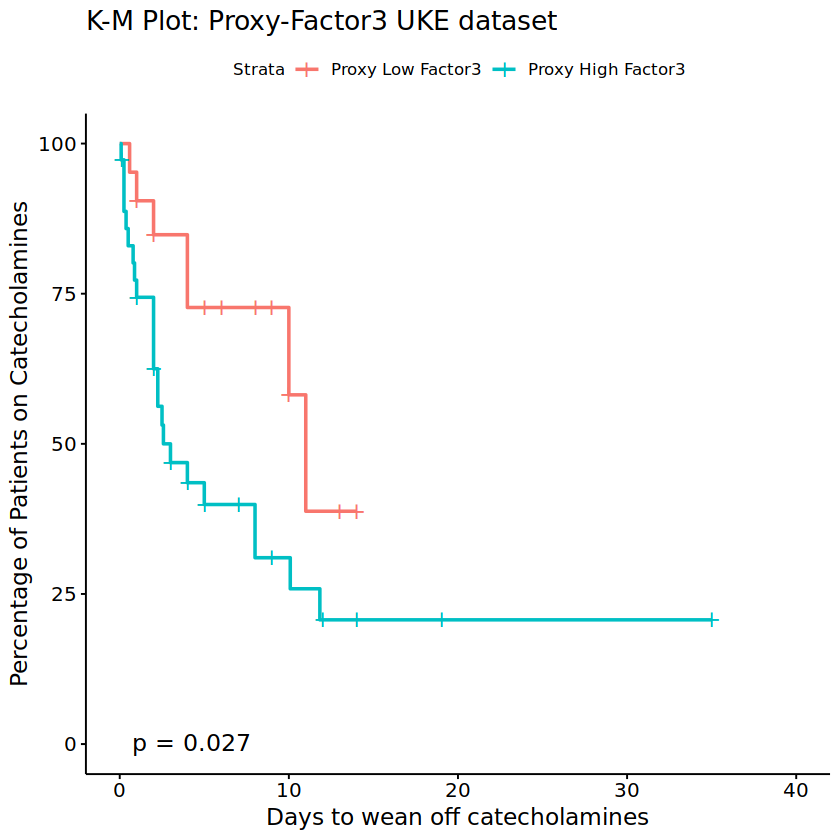

In [31]:
# Create a new column in df for stratifying patients based on the cutpoint

print(df)
# Fit the Kaplan-Meier survival model, stratifying by the FactorCluster
fit <- survfit(Surv(time, event) ~ FactorCluster, data = df)
fit
summary(fit)
# Create the Kaplan-Meier plot
km_plot <- ggsurvplot(
  fit,
  data = df,
  conf.int = FALSE,  # Show confidence intervals
  pval = TRUE,      # Show p-value
  fun = function(y) y * 100,  # Transform y-axis to percentages
  legend = "top",
censor = TRUE,
  risk.table = TRUE,
  legend.labs = c("Proxy Low Factor3", "Proxy High Factor3"),  # Rename the legend labels
  xlab = "Days to wean off catecholamines",  # X-axis label
  ylab = "Percentage of Patients on Catecholamines",  # Y-axis label
  title = "K-M Plot: Proxy-Factor3 UKE dataset"  # Plot title
)

# Display the plot
km_plot$plot



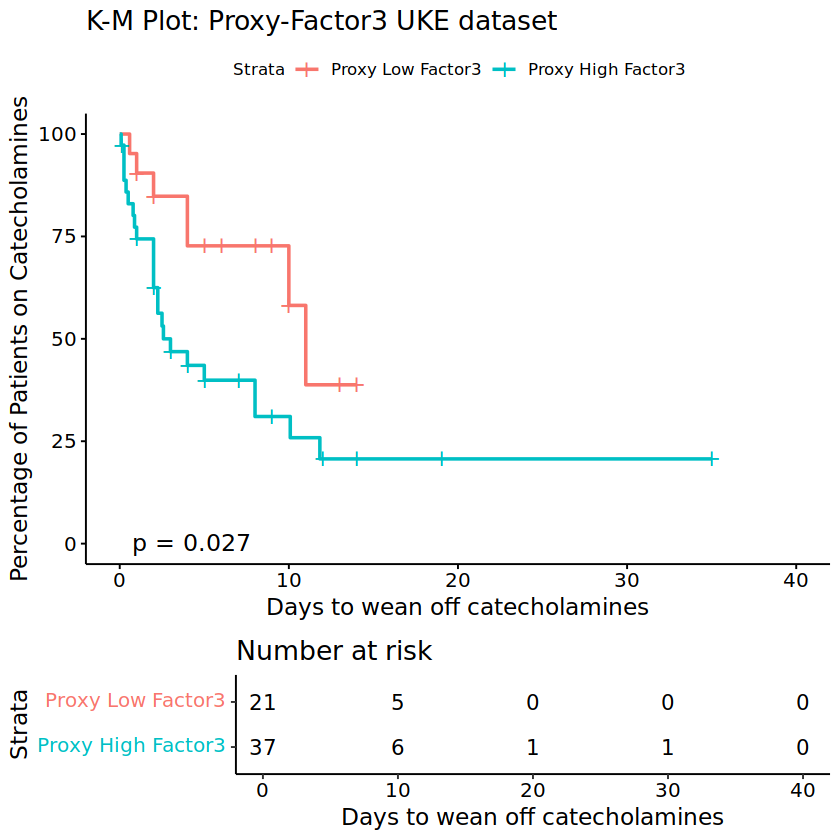

In [32]:
print(km_plot)

In [180]:
write.csv(df,"survival_analysis/kaplar_meier_groups_MEDIAN_ORIGINAL_FACTOR3_LMU_uke_elastic.csv")


In [181]:
p = km_plot
pdf("survival_analysis/kaplar_meier_groups_MEDIAN_ORIGINAL_FACTOR3_LMU_uke_elastic.pdf", width = 8, height = 6)
print(p)
dev.off()

png 
  2

In [ ]:
path = "survival_merged_data_cs_baseline_final_final.csv"
sample_data = read.csv(path)
rownames(sample_data) = sample_data$Labor.IDs
head(sample_data)


In [134]:
nrow(top_500_factor3_genes)


[1] 112

In [135]:
colnames(sample_data)

[1] "X"                                                                
 [2] "Labor.IDs"                                                        
 [3] "enrol_inclusiondate"                                              
 [4] "enrol_tx_inv_ventilation"                                         
 [5] "dc_1_death_intrahosp"                                             
 [6] "dc_1_date_of_death"                                               
 [7] "dc_Dead_death_intrahosp_30_day_binary"                            
 [8] "dc_1_death_intrahosp_30_day"                                      
 [9] "death_30_day"                                                     
[10] "dc_Dead_death_intrahosp_28_day_binary"                            
[11] "dc_1_death_intrahosp_28_day"                                      
[12] "death_28_day"                                                     
[13] "death_14_day"                                                     
[14] "dc_1_death_intrahosp_14_day"                                      
[15] "dc_Dead_death_intrahosp_Dead4_day_binary"                         
[16] "death"                                                            
[17] "death_50_day"                                                     
[18] "dc_1_death_intrahosp_50_day"                                      
[19] "dc_1_discharge"                                                   
[20] "dc_1_dischargedate"                                               
[21] "lactate.clearance..2.mM"                                          
[22] "lacate_clearance_time_days"                                       
[23] "weaning.off.of.catecholamines"                                    
[24] "event_catecholamines"                                             
[25] "time_catecholamines_days"                                         
[26] "need.for.organ.support..MCS..dialysis..intubation.NIV..HTx..LVAD."
[27] "plate"                                                            
[28] "condition"                                                        
[29] "tp"                                                               
[30] "Patient"                                                          
[31] "Day"                                                              
[32] "s1"

In [7]:
df <- data.frame(
  time = sample_data$death_28_day,
  event = sample_data$dc_1_death_intrahosp_28_day,
  Proxy_Factor3 = sample_data[, "s1"]
)
rownames(df) <- rownames(sample_data)
print(df)


           time event Proxy_Factor3
LCLC100040   28     0  -0.074626912
LCLC100111   28     0   0.121207917
LCLC100050   17     0  -0.054151954
LCLC100190   14     0  -0.364712967
LCLC100359   14     0  -0.753160299
LCLC100227   12     0  -0.535106478
LCLC100216   11     0  -0.539241566
LCLC100231    6     0   0.192167011
LCLC100337    6     0  -0.001548929
LCLC100340    6     0  -0.175940614
LCSC100033   11     0   0.130412836
LCSC100058    8     0  -0.188259588
LCSC100059    1     0   0.412416315
LCLC100065   26     1  -0.218308327
LCLC100230   28     0  -0.830495811
LCLC100188   28     0  -0.796853903
LCLC100233   28     0   0.034487708
LCLC100172   28     0  -0.796807085
LCLC100185   28     0   0.356110740
LCLC100199   23     0   0.305811534
LCLC100193   20     0   0.036309918
LCLC100226   14     0  -0.297415563
LCLC100228   12     0  -0.562030443
LCLC100214   10     0  -1.110610507
LCLC100219   10     0  -0.786722836
LCLC100220   10     0  -0.471485108
LCLC100229    8     0  -0.21

In [8]:
nrow(df)

[1] 112

In [9]:
cut <- surv_cutpoint(df, variables='Proxy_Factor3')
cut
df$FactorCluster <- df$Proxy_Factor3 > cut$cutpoint$cutpoint

                cutpoint statistic
Proxy_Factor3 -0.3374595   1.91648

           time event Proxy_Factor3 FactorCluster
LCLC100040   28     0  -0.074626912          TRUE
LCLC100111   28     0   0.121207917          TRUE
LCLC100050   17     0  -0.054151954          TRUE
LCLC100190   14     0  -0.364712967         FALSE
LCLC100359   14     0  -0.753160299         FALSE
LCLC100227   12     0  -0.535106478         FALSE
LCLC100216   11     0  -0.539241566         FALSE
LCLC100231    6     0   0.192167011          TRUE
LCLC100337    6     0  -0.001548929          TRUE
LCLC100340    6     0  -0.175940614          TRUE
LCSC100033   11     0   0.130412836          TRUE
LCSC100058    8     0  -0.188259588          TRUE
LCSC100059    1     0   0.412416315          TRUE
LCLC100065   26     1  -0.218308327          TRUE
LCLC100230   28     0  -0.830495811         FALSE
LCLC100188   28     0  -0.796853903         FALSE
LCLC100233   28     0   0.034487708          TRUE
LCLC100172   28     0  -0.796807085         FALSE
LCLC100185   28     0   0.356110740          TRUE


Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                     n events median 0.95LCL 0.95UCL
FactorCluster=FALSE 36     15     NA      10      NA
FactorCluster=TRUE  76     18     NA      NA      NA

Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                FactorCluster=FALSE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     36       4    0.889  0.0524        0.792        0.998
    2     32       1    0.861  0.0576        0.755        0.982
    5     29       1    0.831  0.0628        0.717        0.964
    6     28       3    0.742  0.0742        0.610        0.903
    8     25       1    0.713  0.0770        0.577        0.881
    9     24       2    0.653  0.0812        0.512        0.833
   10     22       1    0.624  0.0828        0.481        0.809
   13     14       1    0.579  0.0880        0.430        0.780
   14     13       1    0.534  0.0918        0.382        0.748

                FactorCluster=TRUE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     76       3    0.961  0.0223        0.918        1.000
    2     72       1    0.947  0.0257        0.898        0.999
    3     71       1   

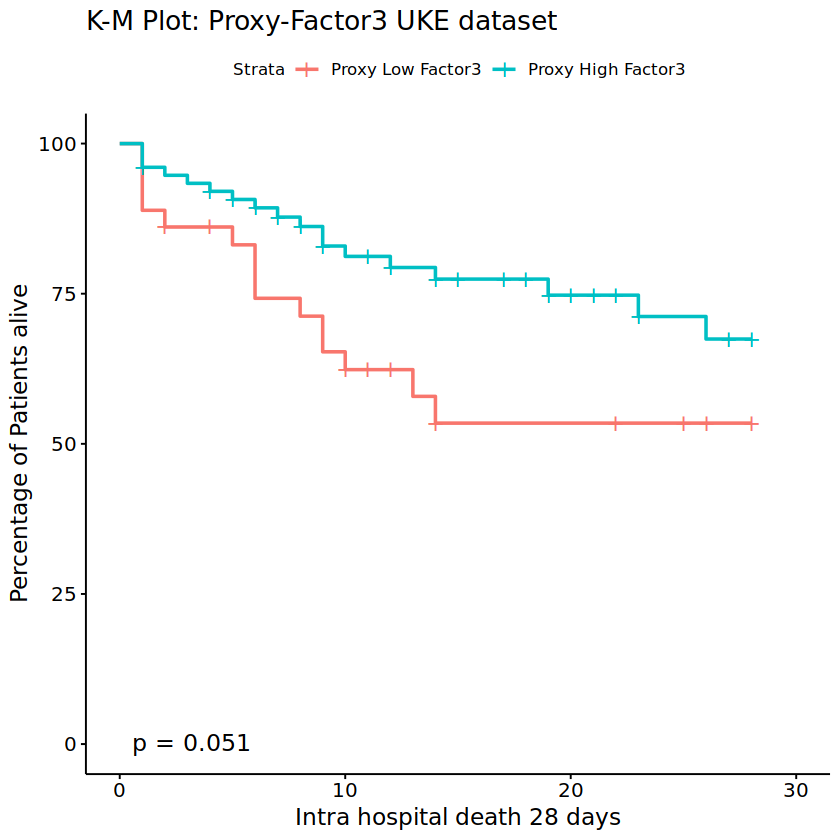

In [10]:
# Create a new column in df for stratifying patients based on the cutpoint

print(df)
# Fit the Kaplan-Meier survival model, stratifying by the FactorCluster
fit <- survfit(Surv(time, event) ~ FactorCluster, data = df)
fit
summary(fit)
# Create the Kaplan-Meier plot
km_plot <- ggsurvplot(
  fit,
  data = df,
  conf.int = FALSE,  # Show confidence intervals
  pval = TRUE,      # Show p-value
  fun = function(y) y * 100,  # Transform y-axis to percentages
  legend = "top",
censor = TRUE,
  risk.table = TRUE,
  legend.labs = c("Proxy Low Factor3", "Proxy High Factor3"),  # Rename the legend labels
  xlab = "Intra hospital death 28 days",  # X-axis label
  ylab = "Percentage of Patients alive",  # Y-axis label
  title = "K-M Plot: Proxy-Factor3 UKE dataset"  # Plot title
)

# Display the plot
km_plot$plot



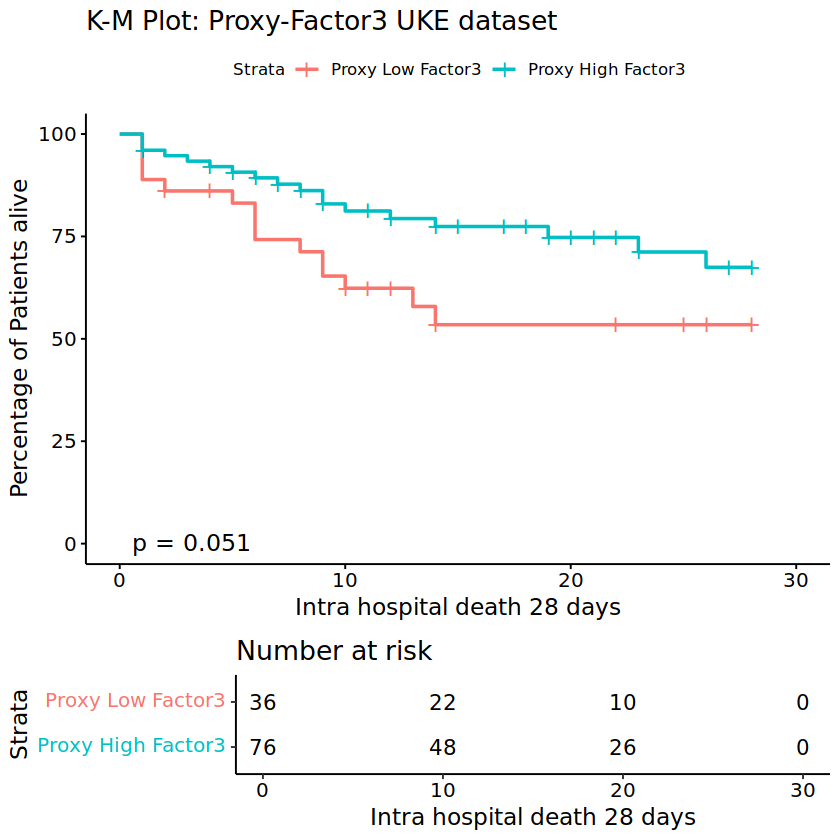

In [11]:
print(km_plot)

In [12]:
write.csv(df,"survival_analysis/kaplar_meier_groups_28_day_mortality_survcutpoint_-0.3374595_uke1.csv")

In [13]:
p = km_plot
pdf("survival_analysis/kaplar_meier_groups_kaplar_meier_groups_28_day_mortality_survcutpoint_-0.3374595_uke1.pdf", width = 8, height = 6)
print(p)
dev.off()

png 
  2